Lex Albrandt  
SYSC410  
Data Adventure 1  

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Pipeline Step 1: Data loading and inspection  
  
The first step in our ML pipeline is loading the csv file using the `pandas` library. 
We will also output the first 10 rows of data to inspect. 

In [2]:
df = pd.read_csv('../data/skyserver_classroom.csv')
print(df.head(10))
print(f"\nData Rows and Columns: {df.shape}")

    class  redshift     mag_u     mag_g     mag_r     mag_i     mag_z  \
0    STAR -0.000426  21.14086  20.16528  19.69889  19.51624  19.52510   
1    STAR  0.000388  24.93039  23.32141  21.01002  20.01553  19.49703   
2  GALAXY  0.102577  19.14357  17.76328  17.13229  16.74271  16.48668   
3  GALAXY  0.121415  19.87450  18.51950  17.75688  17.37121  17.06570   
4  GALAXY  0.386381  23.68880  21.90990  19.83497  19.15776  18.68194   
5     QSO  3.074680  24.82706  21.76440  21.39773  21.18752  21.35631   
6    STAR -0.000527  19.86338  18.79915  18.36247  18.18673  18.12729   
7     QSO  1.468929  20.80588  20.55103  20.31556  20.11175  19.95692   
8    STAR  0.000112  17.18493  16.11148  15.98004  15.96251  16.00853   
9  GALAXY  0.614279  23.65272  22.68763  20.98271  19.97448  19.42359   

           ra        dec      u_g      g_r      r_i      i_z  
0  300.699820 -11.040715  0.97558  0.46639  0.18265 -0.00886  
1  183.448240  26.267395  1.60898  2.31139  0.99449  0.51850  
2  147.

From the output above we can see that our dataset has 1500 rows and 13 columns. 
The columns of our data are as follows:  
- ID
  - Object ID
- Class
   - Object Class
- Redshift
  - Measures how much light from an object has been stretched due to the 
expansion of the universe
- mag_u
  - Ultraviolet wavelength magnitude
- mag_g
  - Green wavelength magnitude
- mag_r
  - Red wavelength magnitude
- mag_i
  - Near-infrared wavelength magnitude
- mag_z
  - Infrared wavelength magnitude
- ra
  - Right Ascension: horizontal position in degrees
- dec
  - Declination: vertical position in degrees
- u_g
  - $\text{u\_g} = \text{mag\_u} - \text{mag\_g}$
  - Color index between $u$ and $g$ bands
- g_r
  - $\text{g\_r} = \text{mag\_g} - \text{mag\_r}$
  - Color index between $g$ and $r$ bands
- r_i
  - $\text{r\_i} = \text{mag\_r} - \text{mag\_i}$
  - Color index between $r$ and $i$ bands
- i_z
  - $\text{i\_z} = \text{mag\_i} - \text{mag\_z}$
  - Color index between $i$ and $z$ bands
  
There are also 3 classes in this dataset: Star, Galaxy, and QSO (quasar).  

Now we want to check for missing values.

In [3]:
missing_count = df.isna().sum()
print(missing_count)

class       0
redshift    0
mag_u       0
mag_g       0
mag_r       0
mag_i       0
mag_z       0
ra          0
dec         0
u_g         0
g_r         0
r_i         0
i_z         0
dtype: int64


Based on the output above there are no missing values in the dataset.
  
## Pipeline Step 2: Explore
  
The next step in our ML pipeline is exploration of the data, which includes  
visualizing our data using a Scatter Plot, and using `pairplot` to determine which
features separate our classes. We can do this with the `matplotlib` library.  
Our target vector in this dataset will be the `Class` column. 
Our feature matrix will be all other columns. We can also examine the distributions 
for each class to determine if our dataset is imbalanced.

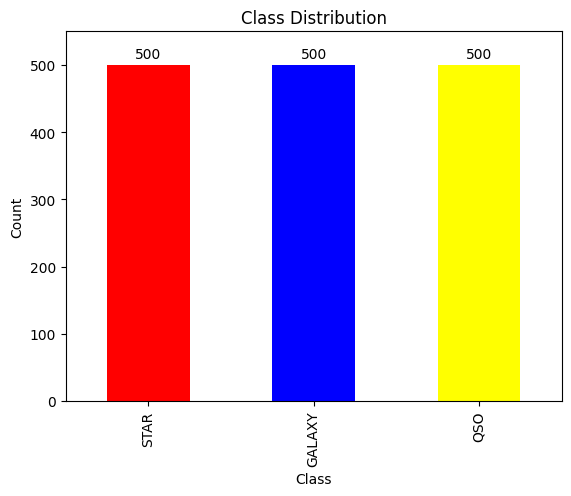

In [4]:
X_feat = df.drop('class', axis = 1)
y_tar = df['class']

counts = y_tar.value_counts()
colors = ["red", "blue", "yellow"]

ax = counts.plot(kind="bar", color = colors)
ax.bar_label(ax.containers[0], padding = 3)
plt.xlabel("Class")
plt.ylabel("Count")
plt.margins(y=0.1)
plt.title("Class Distribution")
plt.show()

From the graph above we can see that all classes have equal distribution. So our 
dataset is balanced. The next step in the exploration process is to see if we can 
find any features that separate the classes. We can do this using `pariplot` from 
the `seaborn` library. Since the pairplot is so large with all feature columns, 
we will break it up into a few different pairplots to better visualize the data.  
In the lines below we have separated the data into three subsets of our original 
dataframe.   
  

In [5]:
ra_mag = df[["class", "ra", "mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]]
bands_red = df[["class", "dec", "redshift", "u_g", "g_r", "r_i", "i_z"]]

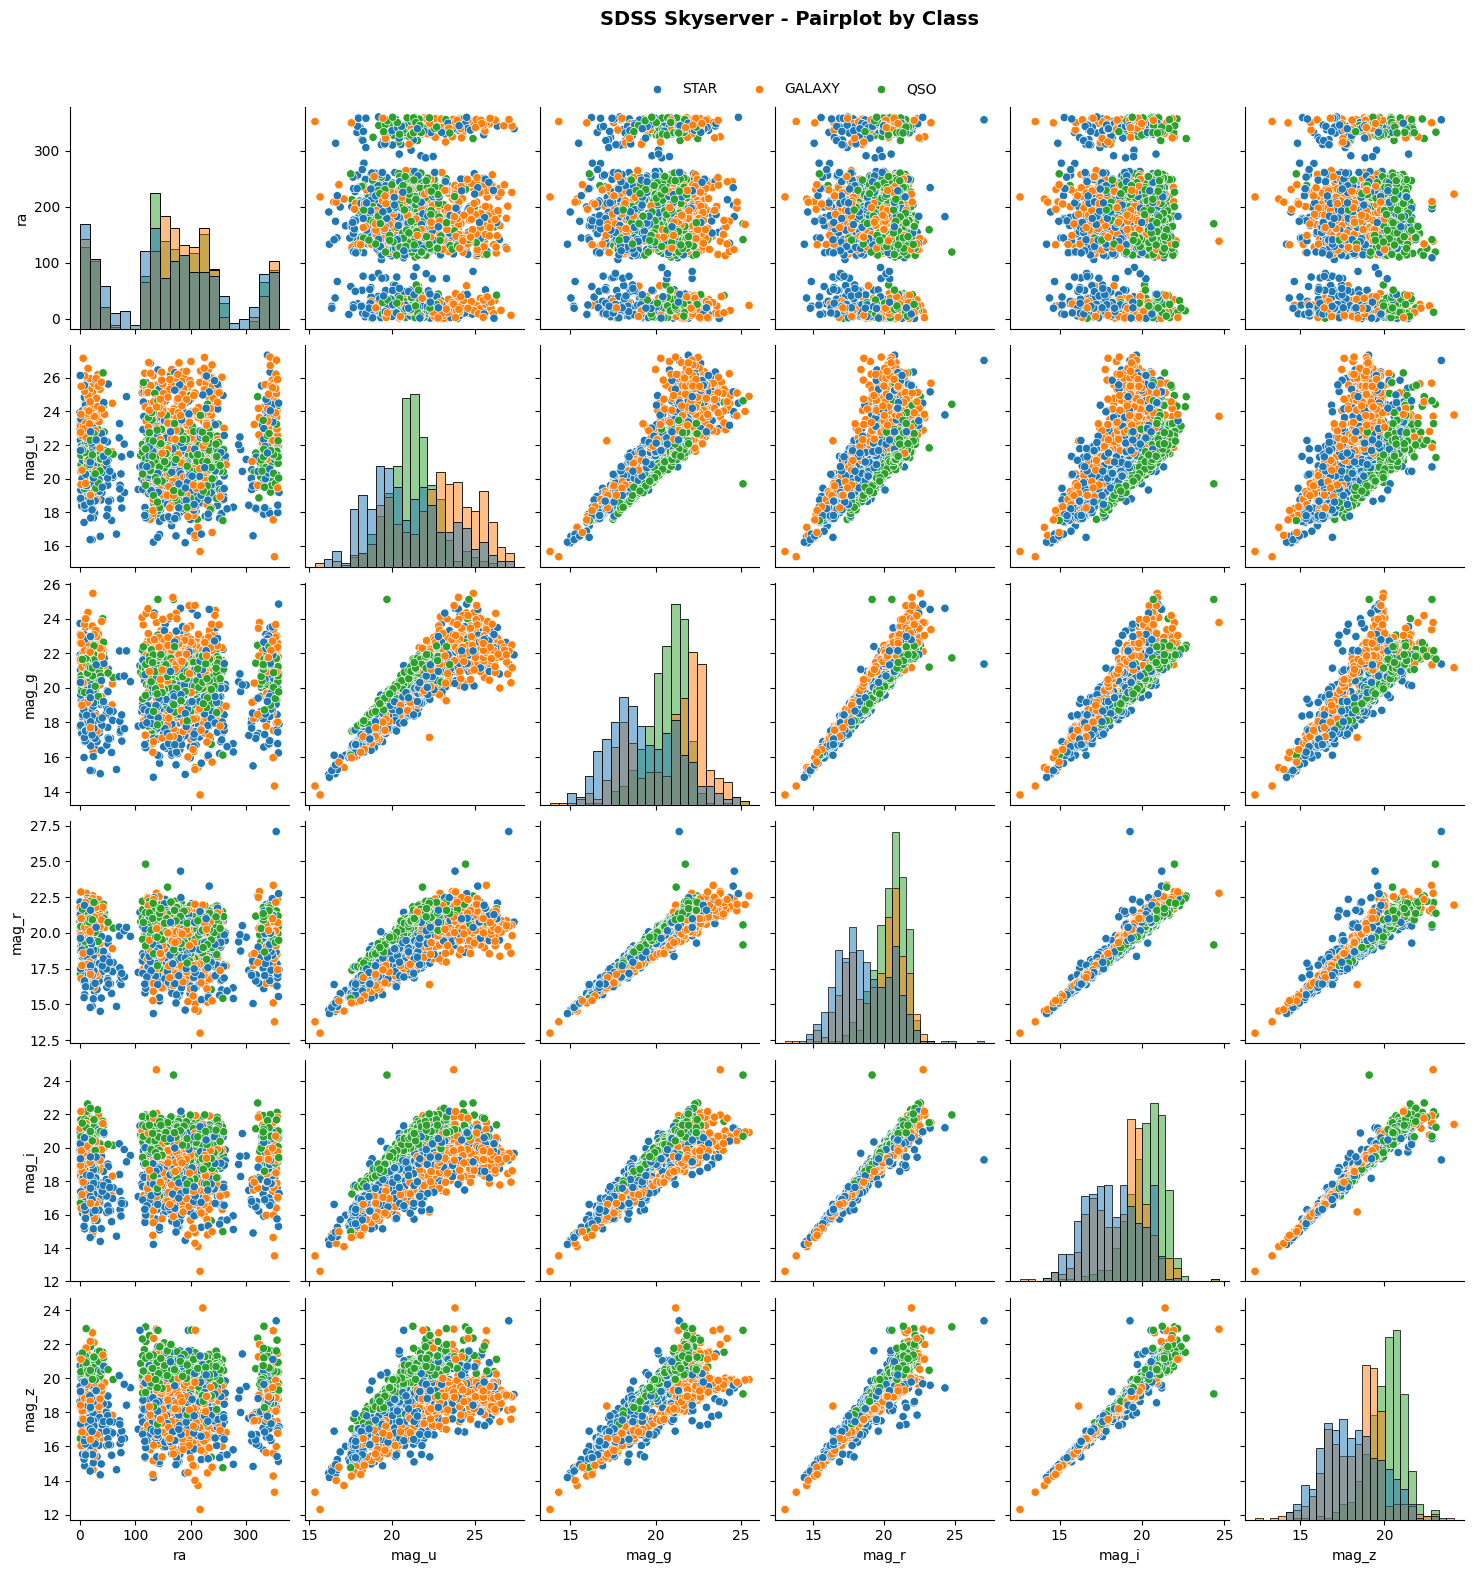

In [6]:
fig_1 = sns.pairplot(ra_mag, hue="class", diag_kind = "hist")
fig_1.figure.suptitle("SDSS Skyserver - Pairplot by Class", y = 1.05, fontsize = 14, fontweight = 'bold')
sns.move_legend(fig_1, "upper center", bbox_to_anchor = (0.5, 1.01), ncol = 3, title = None, frameon = False)
plt.show()

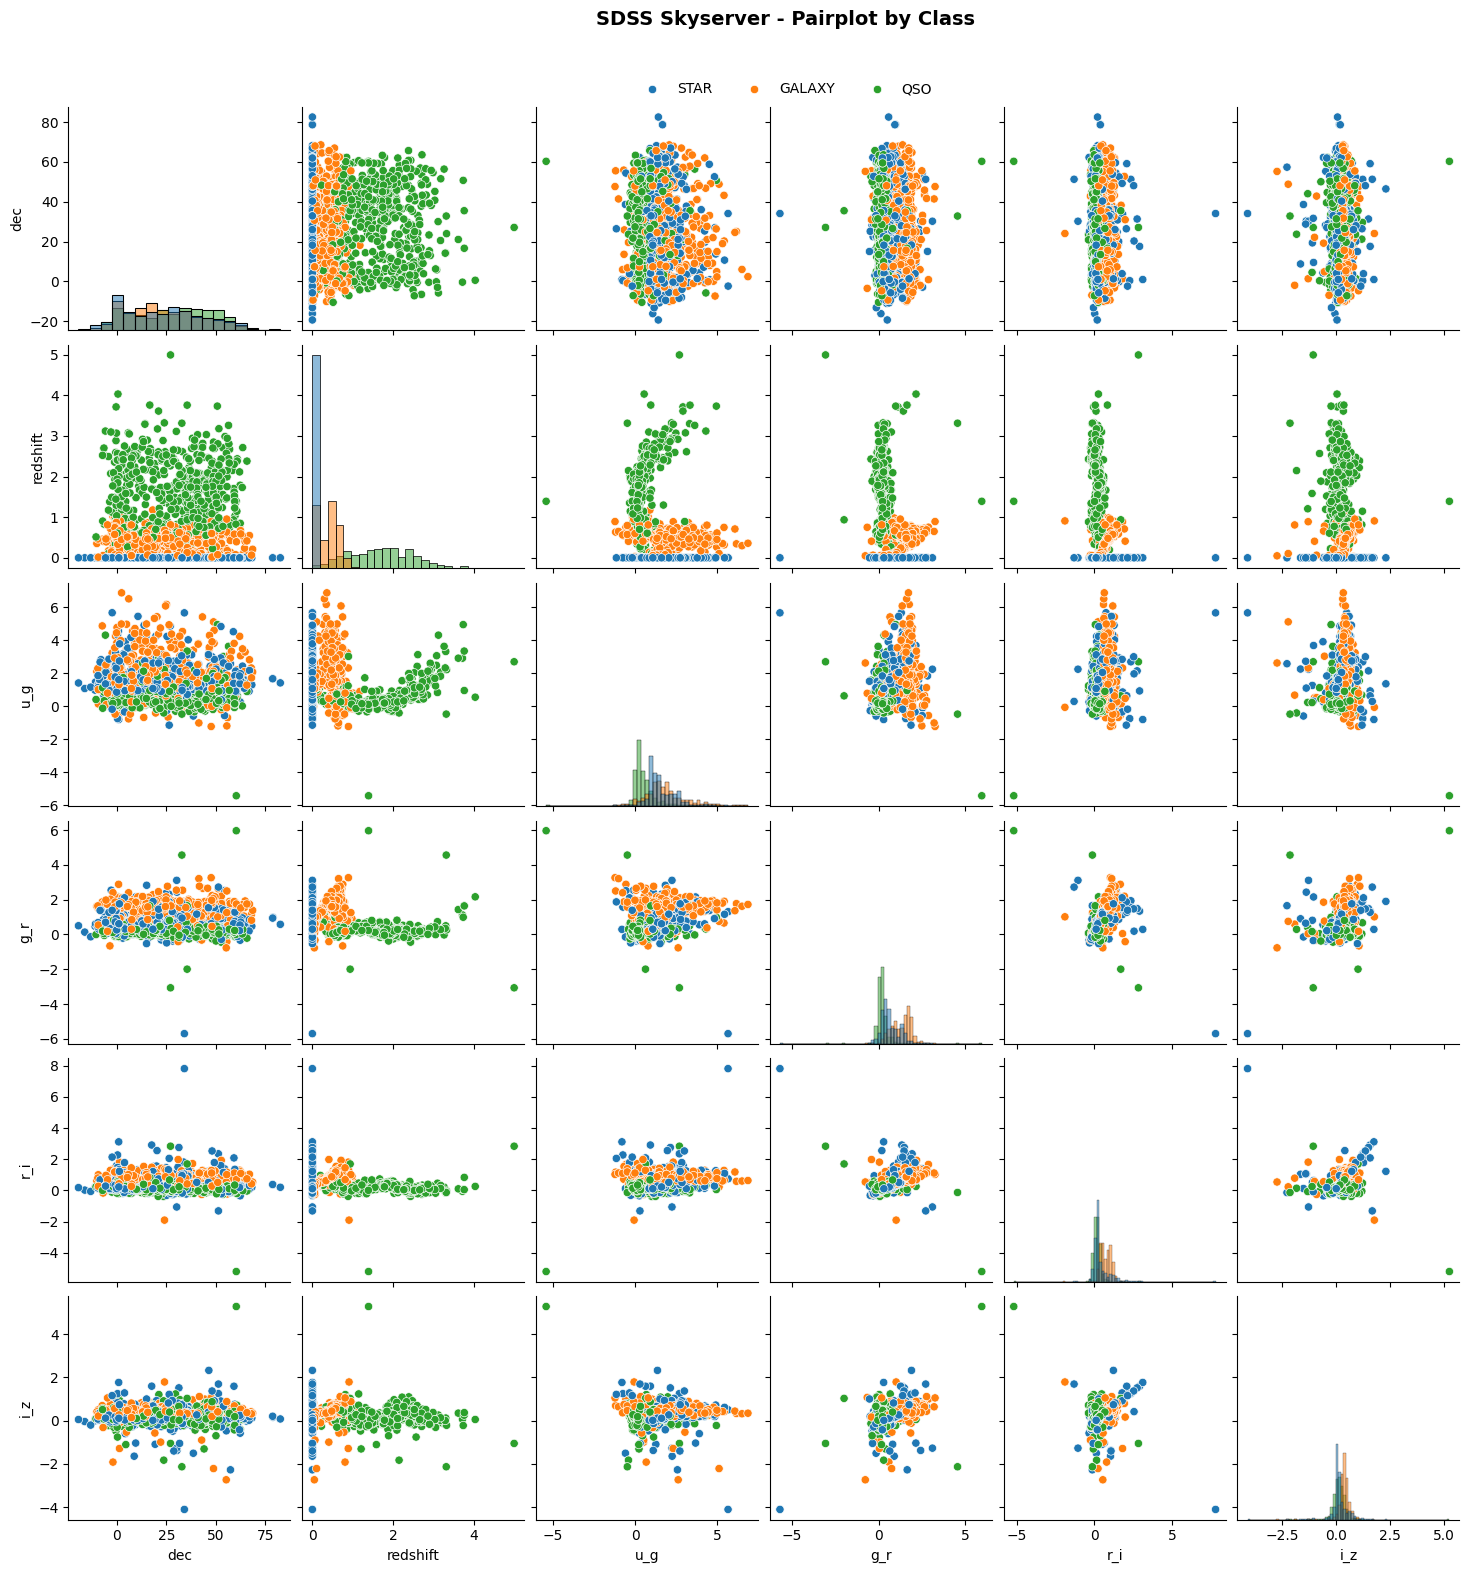

In [7]:
fig_2 = sns.pairplot(bands_red, hue="class", diag_kind = "hist")
fig_2.figure.suptitle("SDSS Skyserver - Pairplot by Class", y = 1.05, fontsize = 14, fontweight = 'bold')
sns.move_legend(fig_2, "upper center", bbox_to_anchor = (0.5, 1.01), ncol = 3, title = None, frameon = False)
plt.show()

From our pairplots above we can see that there is a lot of overlap in many of the categories. 
The category that provides the most separtation is `redshift` when comparing to 
color indices.  
  
## Correlation matrix  
  

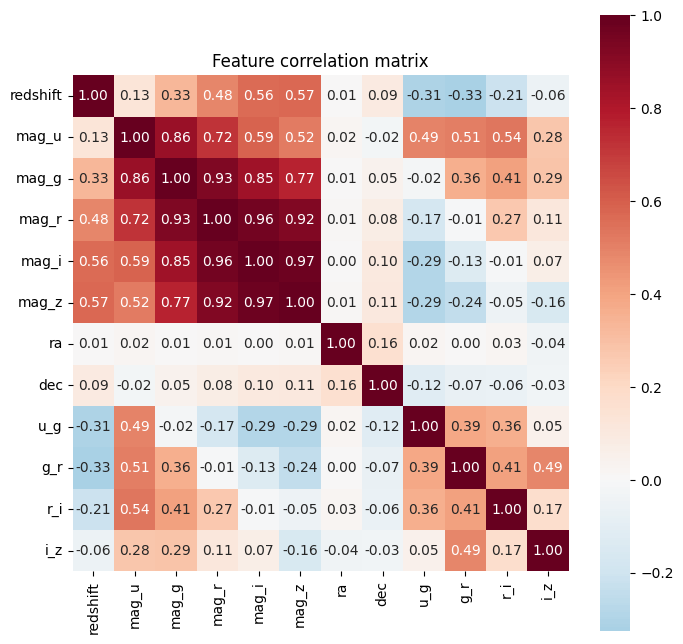

In [8]:
# All columns are already numeric columns
corr = X_feat.corr()
plt.figure(figsize = (8, 8))
sns.heatmap(corr, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Feature correlation matrix")
plt.show()

The correlation matrix above shows a high correlation between all of the wavelength 
magnitudes. We can make a correlation matrix that uses a subset to get a better 
view those correlations.

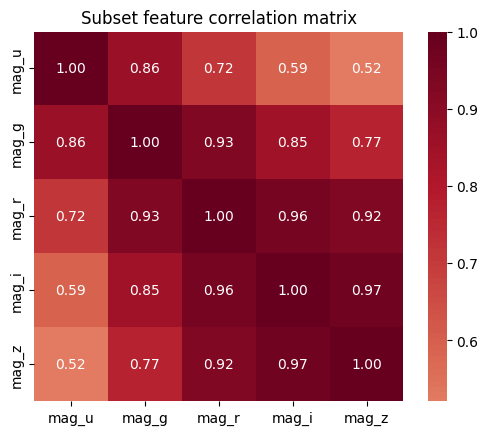

In [9]:
features = df[["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]]
corr_2 = features.corr()
sns.heatmap(corr_2, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Subset feature correlation matrix")
plt.show()

Based on the two correlation matrices and our pairplot, it is reasonable at this 
point in the exploration to drop the magnitude columns, and the `ra` and `dec` 
columns. The magnitude columns can be dropped because of high correlation, and 
`ra` and `dec` can be dropped because they are _positional_ values, and do not 
aid us in classification. We can look at using PCA later if we decide to use 
any of the magnitude columns for classifcation or regression.
  

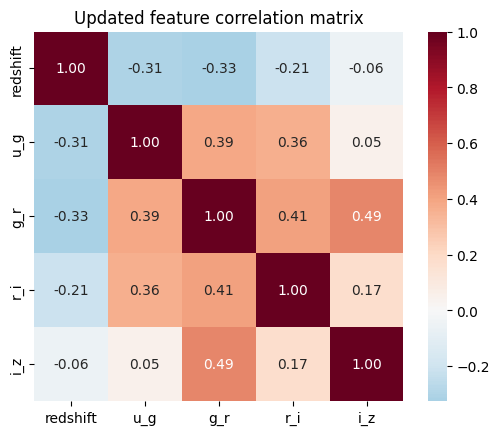

In [10]:
# Update X-feat
X_feat = df[["redshift", "u_g", "g_r", "r_i", "i_z"]]

# Updated correlation matrix
corr_3 = X_feat.corr()
sns.heatmap(corr_3, annot = True, fmt = "0.2f", cmap = "RdBu_r", center = 0, square = True)
plt.title("Updated feature correlation matrix")
plt.show()